# 3 глава. Первичный анализ набора данных с изображениями

Набор данных: **Hard Hat Workers Dataset**  
Тип задачи: **детекция объектов**  
Формат разметки: **YOLO**

Ноутбук содержит основные этапы первичного анализа: баланс классов, примеры изображений с разметкой, характеристики изображений и плотность аннотаций.

## 1. Импорт библиотек и подготовка параметров

In [ ]:
import os, random, yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter

# Папка для сохранения рисунков
OUT = 'графики_глава_3'
os.makedirs(OUT, exist_ok=True)

# Читаю классы из data.yaml
with open('data.yaml', 'r') as f:
    data = yaml.safe_load(f)

classes = data['names']
splits = ['train', 'valid', 'test']

## 2. Анализ количества и баланса классов

**Рисунок 14. Распределение объектов по классам**

,Класс,Количество объектов,"Доля, %"
0,head,6677,24.69
1,helmet,19747,73.03
2,person,615,2.27


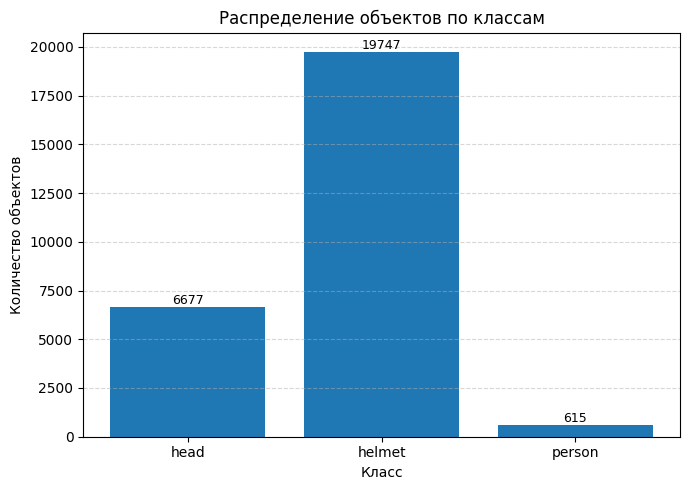

In [24]:
# Анализ количества и баланса классов



class_count = Counter()

# объекты всех классов во всех выборках
for split in splits:
    labels_dir = f'{split}/labels'

    for file in os.listdir(labels_dir):
        if file.endswith('.txt'):
            with open(os.path.join(labels_dir, file), 'r') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]

            for line in lines:
                class_id = int(line.split()[0])
                class_count[class_id] += 1

# таблицу с количеством объектов и долей каждого класса
class_df = pd.DataFrame({
    'Класс': classes,
    'Количество объектов': [class_count[i] for i in range(len(classes))]
})

class_df['Доля, %'] = round(
    class_df['Количество объектов'] / class_df['Количество объектов'].sum() * 100,
    2
)

display(class_df)

# одну диаграмму распределения классов
plt.figure(figsize=(7, 5))
bars = plt.bar(class_df['Класс'], class_df['Количество объектов'])

# Подписываю значения над столбцами
for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Рисунок 14. Распределение объектов по классам')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(f'{OUT}/рисунок_1_баланс_классов.jpg', dpi=300)
plt.show()

## 3. Примеры типичных изображений с разметкой

**Рисунки 15-17. Примеры изображений с нанесёнными ограничивающими рамками**

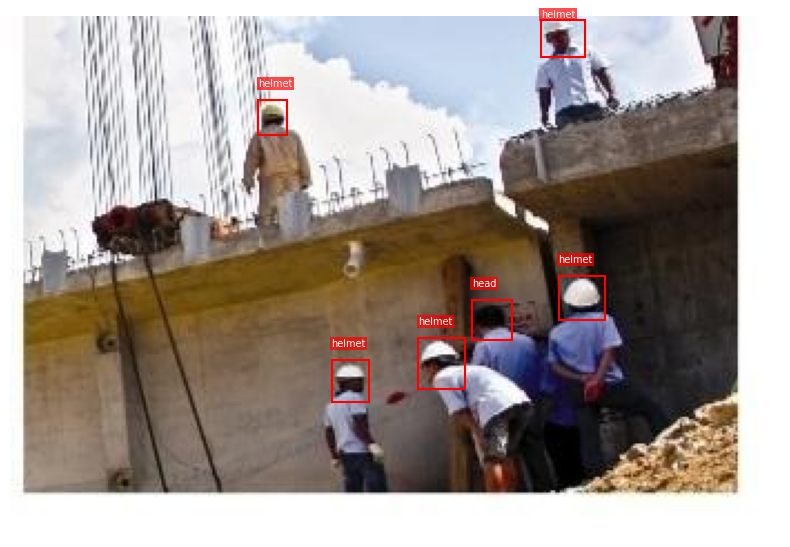

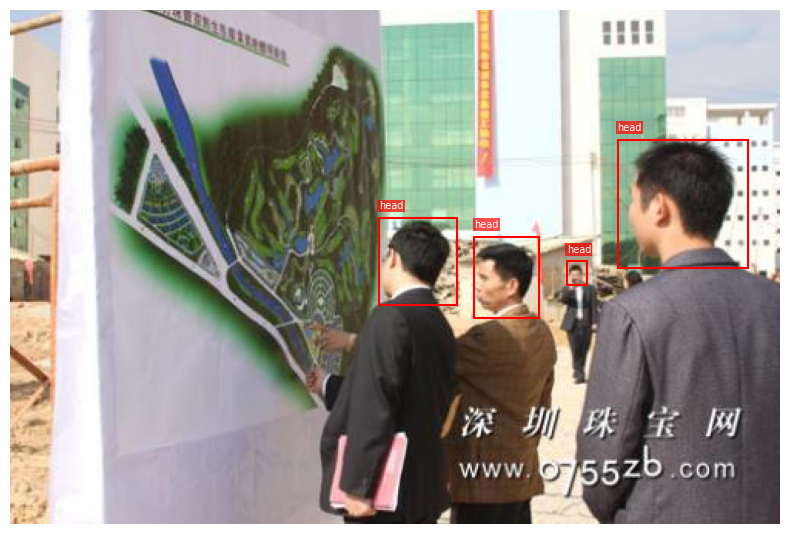

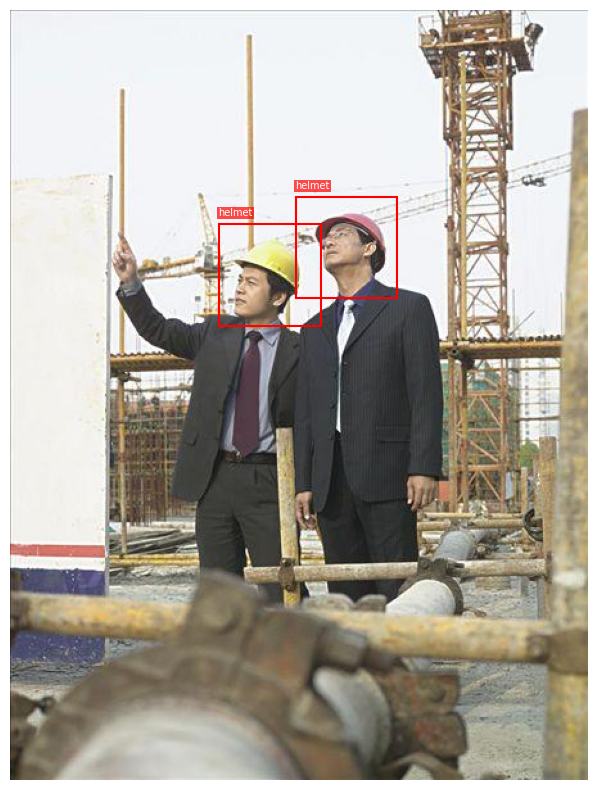

3 примера изображений с рамками успешно сохранены.


In [31]:
# ---------------------------------------------------------
# Примеры типичных изображений с разметкой
# ---------------------------------------------------------


IMAGES_DIR = 'train/images'
LABELS_DIR = 'train/labels'
OUTPUT_DIR = 'графики_для_отчета_гл3'

os.makedirs(OUTPUT_DIR, exist_ok=True)

image_files = [
    f for f in os.listdir(IMAGES_DIR)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

if len(image_files) >= 3:
    sample_images = random.sample(image_files, 3)

    for idx, img_name in enumerate(sample_images, 1):
        img_path = os.path.join(IMAGES_DIR, img_name)
        txt_name = os.path.splitext(img_name)[0] + '.txt'
        txt_path = os.path.join(LABELS_DIR, txt_name)

        img = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(img)

        if os.path.exists(txt_path):
            with open(txt_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()

                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        x_center, y_center, width, height = map(float, parts[1:5])

                        xmin = (x_center - width / 2) * img_w
                        ymin = (y_center - height / 2) * img_h
                        box_w = width * img_w
                        box_h = height * img_h

                        rect = patches.Rectangle(
                            (xmin, ymin),
                            box_w,
                            box_h,
                            linewidth=1.5,
                            edgecolor='red',
                            facecolor='none'
                        )
                        ax.add_patch(rect)

                        label_text = classes[class_id]
                        ax.text(
                            xmin,
                            max(0, ymin - 6),
                            label_text,
                            color='white',
                            fontsize=7,
                            bbox=dict(facecolor='red', edgecolor='none', alpha=0.7, pad=1)
                        )

        ax.axis('off')
        plt.tight_layout()
        plt.savefig(
            f'{OUTPUT_DIR}/рисунок_пример_разметки_{idx}.jpg',
            dpi=300,
            bbox_inches='tight',
            pad_inches=0.02
        )
        plt.show()
        plt.close()

    print('3 примера изображений с рамками успешно сохранены.')
else:
    print('ОШИБКА: Недостаточно изображений для генерации примеров.')

## 4. Оценка качества изображений

**Таблица 7. Характеристика изображений в наборе данных**

In [32]:
# -------------------------------------------------
# Оценка качества изображений
# -------------------------------------------------


splits = ['train', 'valid', 'test']
OUT = 'графики_глава_3'
os.makedirs(OUT, exist_ok=True)

image_info = []

# Прохожу по train, valid и test
for split in splits:
    img_dir = f'{split}/images'

    for img_name in os.listdir(img_dir):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(img_dir, img_name)

            img = Image.open(img_path)
            w, h = img.size

            image_info.append({
                'Выборка': split,
                'Файл': img_name,
                'Формат': os.path.splitext(img_name)[1].lower(),
                'Ширина': w,
                'Высота': h,
                'Меньше 512x512': w < 512 or h < 512
            })

image_df = pd.DataFrame(image_info)

# Таблица с общей характеристикой изображений
quality_df = pd.DataFrame([
    ['Количество изображений', len(image_df)],
    ['Форматы изображений', ', '.join(sorted(image_df['Формат'].unique()))],
    ['Минимальная ширина', image_df['Ширина'].min()],
    ['Максимальная ширина', image_df['Ширина'].max()],
    ['Средняя ширина', round(image_df['Ширина'].mean(), 2)],
    ['Минимальная высота', image_df['Высота'].min()],
    ['Максимальная высота', image_df['Высота'].max()],
    ['Средняя высота', round(image_df['Высота'].mean(), 2)],
    ['Изображений меньше 512x512', image_df['Меньше 512x512'].sum()]
], columns=['Показатель', 'Значение'])

display(quality_df)

# Сохраняю таблицу
quality_df.to_csv(f'{OUT}/таблица_качество_изображений.csv', index=False, encoding='utf-8-sig')

,Показатель,Значение
0,Количество изображений,7035
1,Форматы изображений,.jpg
2,Минимальная ширина,167
3,Максимальная ширина,1100
4,Средняя ширина,477.06
5,Минимальная высота,126
6,Максимальная высота,965
7,Средняя высота,358.58
8,Изображений меньше 512x512,6976


## 5. Плотность разметки

**Рисунок 19. Распределение количества объектов на изображении**

,Количество объектов на изображении,Количество изображений
0,1,1736
1,2,1654
2,3,848
3,4,699
4,5,479
5,6,390
6,7,280
7,8,252
8,9,188
9,10,163


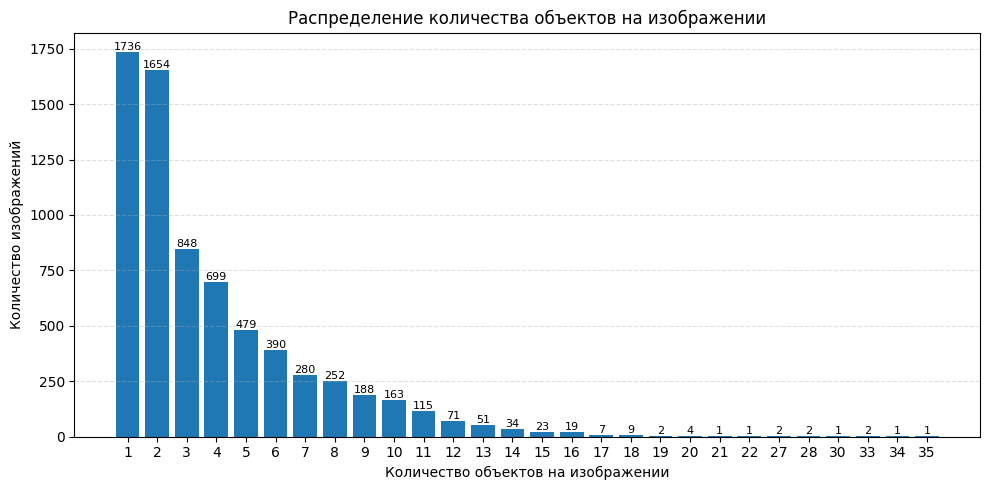

In [33]:
# -------------------------------------------------
# Пункт 4. Плотность разметки: количество объектов на изображении
# -------------------------------------------------


objects_per_image = []

# Считаю, сколько объектов указано в каждом txt-файле
for split in ['train', 'valid', 'test']:
    labels_dir = f'{split}/labels'

    for file in os.listdir(labels_dir):
        if file.endswith('.txt'):
            with open(os.path.join(labels_dir, file), 'r') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]

            objects_per_image.append(len(lines))

# Считаю, сколько изображений имеют 1 объект, 2 объекта, 3 объекта и т.д.
density = Counter(objects_per_image)

density_df = pd.DataFrame({
    'Количество объектов на изображении': sorted(density.keys()),
    'Количество изображений': [density[k] for k in sorted(density.keys())]
})

display(density_df)

# график
plt.figure(figsize=(10, 5))
bars = plt.bar(
    density_df['Количество объектов на изображении'].astype(str),
    density_df['Количество изображений']
)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title('Рисунок 19. Распределение количества объектов на изображении')
plt.xlabel('Количество объектов на изображении')
plt.ylabel('Количество изображений')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{OUT}/рисунок_плотность_разметки.jpg', dpi=300)
plt.show()

## 6. Итог

Ноутбук содержит код для анализа набора изображений: распределение объектов по классам, примеры изображений с YOLO-разметкой, характеристики изображений и плотность разметки.